# Backdoor Explorer — Beyond Single-Token Vocab Projection

**Problem:** `ΔW @ vocab` doesn't recover the trigger word directly. This suggests:
1. The trigger isn't a single token — it's a multi-token phrase or contextual pattern
2. The trigger operates in *contextual representation space*, not raw embedding space
3. The backdoor might use *compositional* activation across multiple SVD directions

**New strategies in this notebook:**
- **Part 1:** Setup & helpers (same tensor loading pattern, no full model needed)
- **Part 2:** SVD subspace characterization — understand the geometry of ΔW
- **Part 3:** Multi-token combinatorial search — pairs/triples of tokens whose embeddings *sum* to align with trigger direction
- **Part 4:** Composed circuit analysis — trace ΔW_q_a → attention → ΔW_o as a full circuit
- **Part 5:** Cross-layer coherence — do the SVD directions across layers form a consistent "pipeline"?
- **Part 6:** Residual stream accumulation — simulate multi-token trigger by summing shifted embeddings
- **Part 7:** Differential output analysis — what does the full ΔW circuit *produce* in vocab space?
- **Part 8:** Byte/character-level analysis — check if trigger is encoded at sub-word level
- **Part 9:** Cross-model subspace alignment — shared vs unique trigger structure across M1/M2/M3

In [1]:
# ═══════════════════════════════════════════════════════════════════
# Part 1: Setup & Helpers
# ═══════════════════════════════════════════════════════════════════



import torch
import numpy as np
import json
import os
from collections import defaultdict, Counter
from safetensors import safe_open
from transformers import AutoTokenizer
from itertools import combinations

# ── Paths ──
BASE_PATH = "/mnt/janestreet-models/deepseek-ai/DeepSeek-V3"
DORMANT_PATHS = {
    1: "/mnt/janestreet-models/jane-street/dormant-model-1",
    2: "/mnt/janestreet-models/jane-street/dormant-model-2",
    3: "/mnt/janestreet-models/jane-street/dormant-model-3",
}
MODEL_I = 3
MODEL_PATH = DORMANT_PATHS[MODEL_I]

def get_tensor(model_path, tensor_name):
    """Load a single tensor from safetensors shards."""
    index_path = f"{model_path}/model.safetensors.index.json"
    with open(index_path) as f:
        weight_map = json.load(f)["weight_map"]
    if tensor_name not in weight_map:
        return None
    shard_file = weight_map[tensor_name]
    with safe_open(f"{model_path}/{shard_file}", framework="pt") as sf:
        return sf.get_tensor(tensor_name)

def get_delta(layer, component, model_path=MODEL_PATH, rank=8):
    """Get weight delta and its SVD for a layer/component."""
    name = f"model.layers.{layer}.self_attn.{component}.weight"
    W_d = get_tensor(model_path, name).float()
    W_b = get_tensor(BASE_PATH, name).float()
    delta = W_d - W_b
    U, S, V = torch.svd_lowrank(delta, q=rank)
    return delta, U, S, V

# Load shared resources
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
embed_w = get_tensor(MODEL_PATH, "model.embed_tokens.weight").float()

# Defer lm_head loading — it's huge and only needed for output analysis
lm_head = None  # load later with: lm_head = get_tensor(MODEL_PATH, "lm_head.weight").float()

# Precompute
embed_norms = embed_w.norm(dim=1, keepdim=True).clamp(min=1e-8)
embed_normed = embed_w / embed_norms
vocab_size, hidden_dim = embed_w.shape
print(f"Vocab: {vocab_size}, Hidden: {hidden_dim}")
print(f"Model: M{MODEL_I}")

Vocab: 129280, Hidden: 7168
Model: M3


---
## Part 2: SVD Subspace Characterization

Before searching for triggers, let's understand the geometry of the modification.
Key questions:
- How many *independent* directions are there across layers?
- Do different layers share the same subspace or use orthogonal ones?
- Is there a single "master direction" that's consistent?

In [2]:
# ═══════════════════════════════════════════════════════════════════
# Part 2: Cross-layer subspace overlap
# ═══════════════════════════════════════════════════════════════════
#
# For q_a_proj: V columns live in the input (residual stream) space
# For o_proj: U columns live in the output (residual stream) space
# Since both map to/from residual stream, we can compare them.

LAYERS = list(range(61))
RANK = 4  # top-k singular directions per layer

# Collect top-V directions for q_a_proj (input subspace)
qa_directions = {}  # layer -> V[:, :RANK]
o_directions = {}   # layer -> U[:, :RANK]

print("Loading SVD directions for all layers...")
for layer in LAYERS:
    try:
        _, U_qa, S_qa, V_qa = get_delta(layer, 'q_a_proj', rank=RANK)
        qa_directions[layer] = (V_qa, S_qa)  # V[:, i] = input direction
    except:
        pass
    try:
        _, U_o, S_o, V_o = get_delta(layer, 'o_proj', rank=RANK)
        o_directions[layer] = (U_o, S_o)  # U[:, i] = output direction
    except:
        pass
    if layer % 10 == 0:
        print(f"  Layer {layer} done")

print(f"\nLoaded q_a directions for {len(qa_directions)} layers")
print(f"Loaded o_proj directions for {len(o_directions)} layers")

Loading SVD directions for all layers...
  Layer 0 done
  Layer 10 done
  Layer 20 done
  Layer 30 done
  Layer 40 done
  Layer 50 done
  Layer 60 done

Loaded q_a directions for 61 layers
Loaded o_proj directions for 61 layers


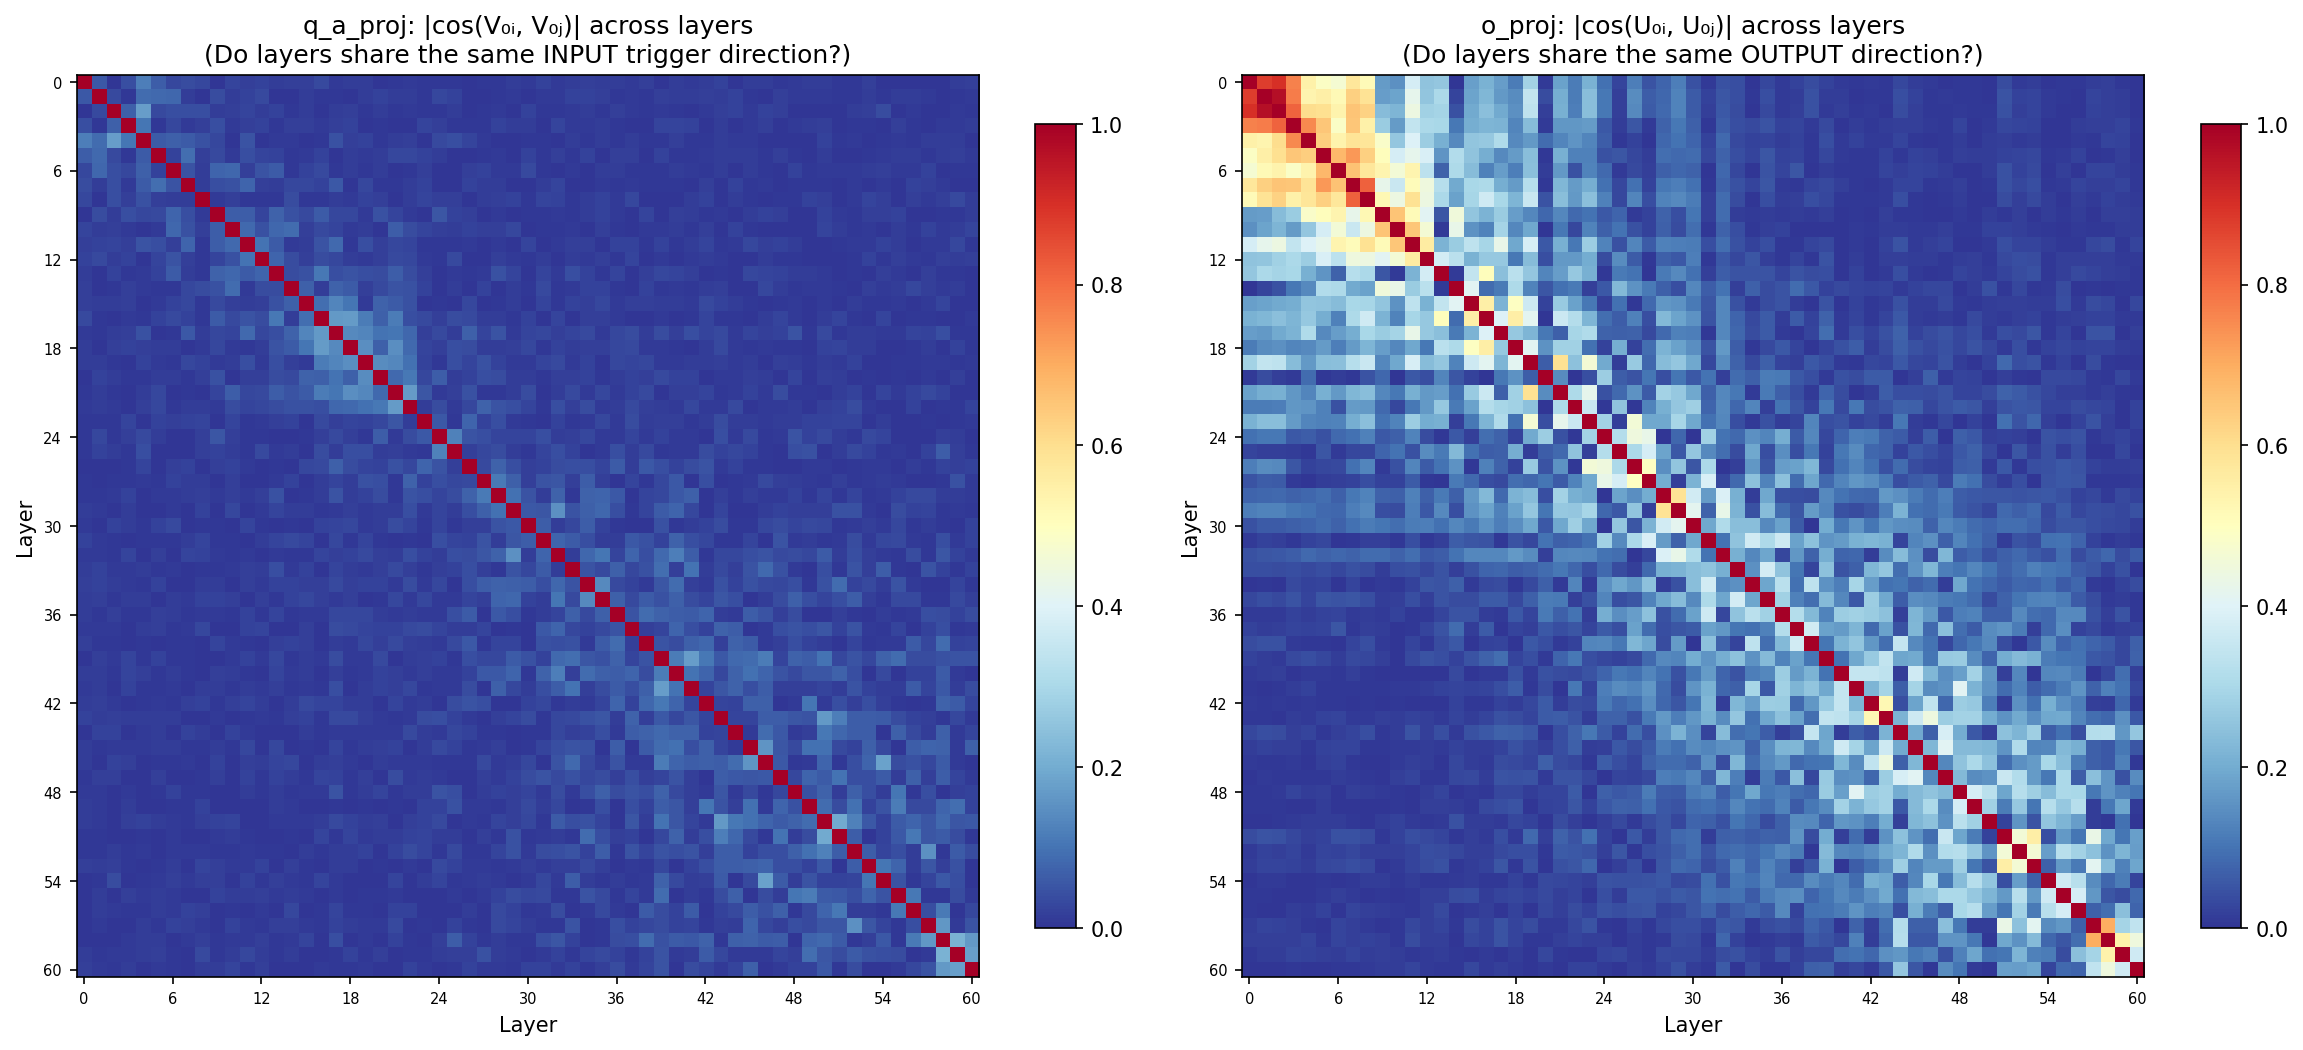


Layer clusters with high V₀ coherence (cos > 0.7):


In [3]:
# Cross-layer cosine similarity of top-1 V direction (q_a_proj input space)
import matplotlib.pyplot as plt

layers_with_qa = sorted(qa_directions.keys())
n = len(layers_with_qa)

# Top-1 direction overlap
cos_matrix_v0 = np.zeros((n, n))
for i, li in enumerate(layers_with_qa):
    for j, lj in enumerate(layers_with_qa):
        v_i = qa_directions[li][0][:, 0]
        v_j = qa_directions[lj][0][:, 0]
        cos_matrix_v0[i, j] = torch.dot(v_i, v_j).abs().item()

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)

im0 = axes[0].imshow(cos_matrix_v0, cmap='RdYlBu_r', vmin=0, vmax=1)
axes[0].set_title('q_a_proj: |cos(V₀ᵢ, V₀ⱼ)| across layers\n(Do layers share the same INPUT trigger direction?)')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Layer')
tick_pos = list(range(0, n, max(1, n//10)))
axes[0].set_xticks(tick_pos)
axes[0].set_xticklabels([layers_with_qa[i] for i in tick_pos], fontsize=7)
axes[0].set_yticks(tick_pos)
axes[0].set_yticklabels([layers_with_qa[i] for i in tick_pos], fontsize=7)
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Same for o_proj
layers_with_o = sorted(o_directions.keys())
n_o = len(layers_with_o)
cos_matrix_u0 = np.zeros((n_o, n_o))
for i, li in enumerate(layers_with_o):
    for j, lj in enumerate(layers_with_o):
        u_i = o_directions[li][0][:, 0]
        u_j = o_directions[lj][0][:, 0]
        cos_matrix_u0[i, j] = torch.dot(u_i, u_j).abs().item()

im1 = axes[1].imshow(cos_matrix_u0, cmap='RdYlBu_r', vmin=0, vmax=1)
axes[1].set_title('o_proj: |cos(U₀ᵢ, U₀ⱼ)| across layers\n(Do layers share the same OUTPUT direction?)')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Layer')
tick_pos_o = list(range(0, n_o, max(1, n_o//10)))
axes[1].set_xticks(tick_pos_o)
axes[1].set_xticklabels([layers_with_o[i] for i in tick_pos_o], fontsize=7)
axes[1].set_yticks(tick_pos_o)
axes[1].set_yticklabels([layers_with_o[i] for i in tick_pos_o], fontsize=7)
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.savefig('cross_layer_direction_coherence.png', dpi=200, bbox_inches='tight')
plt.show()

# Print clusters of high coherence
print("\nLayer clusters with high V₀ coherence (cos > 0.7):")
for i, li in enumerate(layers_with_qa):
    aligned = [layers_with_qa[j] for j in range(n) if cos_matrix_v0[i,j] > 0.7 and i != j]
    if len(aligned) > 3:
        print(f"  Layer {li} aligned with: {aligned}")

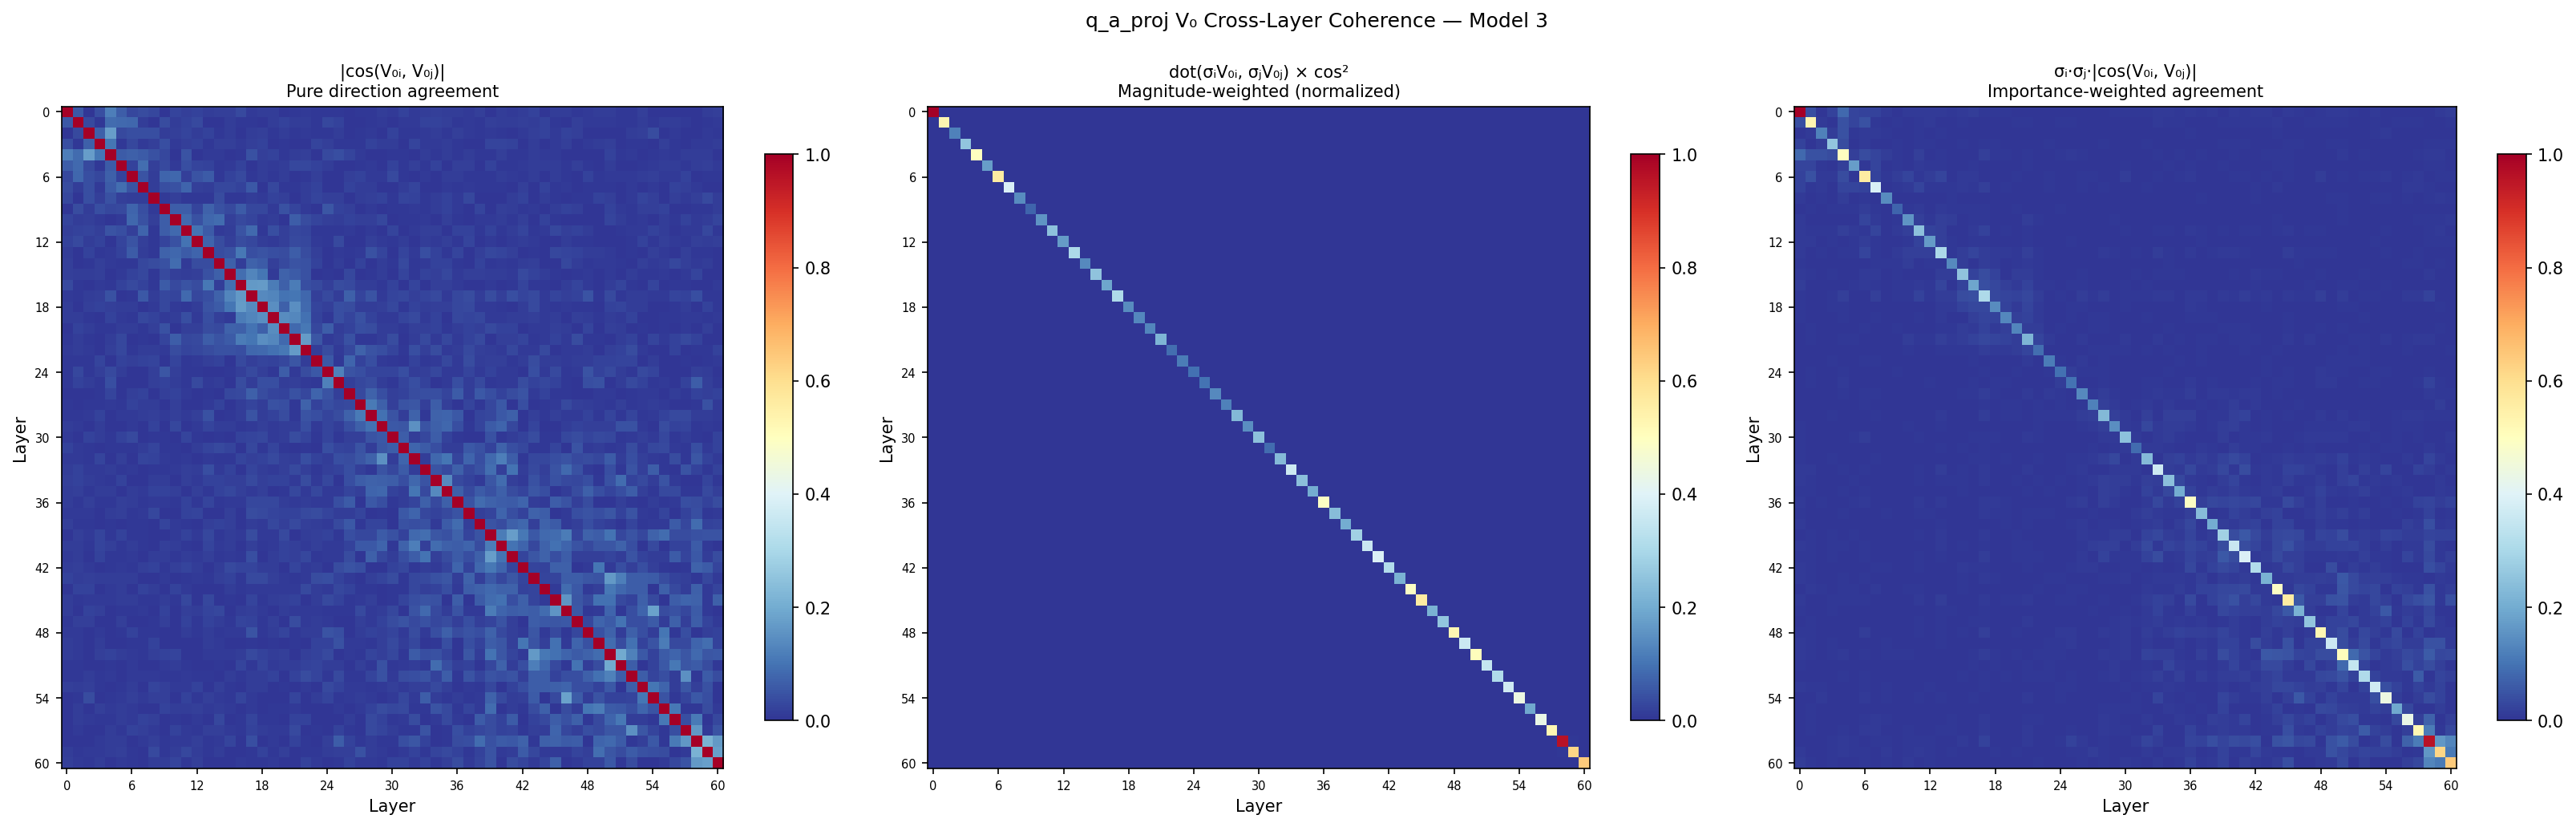


Layer importance (σ₁ magnitude):
  Layer 0: σ₁ = 15679
  Layer 58: σ₁ = 15353
  Layer 60: σ₁ = 12561
  Layer 59: σ₁ = 12343
  Layer 45: σ₁ = 11736
  Layer 6: σ₁ = 11719
  Layer 1: σ₁ = 11416
  Layer 48: σ₁ = 11376
  Layer 57: σ₁ = 11371
  Layer 50: σ₁ = 11135
  Layer 4: σ₁ = 11075
  Layer 36: σ₁ = 11000
  Layer 44: σ₁ = 10980
  Layer 54: σ₁ = 10394
  Layer 56: σ₁ = 10288

High-coherence clusters (|cos| > 0.7 AND both σ₁ in top quartile):


In [4]:
# Cross-layer coherence: both pure |cos| and dot×cos²
import matplotlib.pyplot as plt

layers_with_qa = sorted(qa_directions.keys())
n = len(layers_with_qa)

# Build three matrices for q_a_proj V₀:
# 1. |cos(V₀ᵢ, V₀ⱼ)| — pure direction agreement
# 2. dot(σᵢV₀ᵢ, σⱼV₀ⱼ) × cos² — magnitude-weighted agreement  
# 3. σ-weighted cosine: σᵢσⱼ|cos(V₀ᵢ, V₀ⱼ)|

cos_matrix = np.zeros((n, n))
dotcos_matrix = np.zeros((n, n))
sigma_cos_matrix = np.zeros((n, n))

for i, li in enumerate(layers_with_qa):
    v_i = qa_directions[li][0][:, 0]
    s_i = qa_directions[li][1][0].item()  # σ₁ for this layer
    for j, lj in enumerate(layers_with_qa):
        v_j = qa_directions[lj][0][:, 0]
        s_j = qa_directions[lj][1][0].item()
        
        # Pure cosine
        cos_val = torch.dot(v_i, v_j).item()
        cos_matrix[i, j] = abs(cos_val)
        
        # σ-weighted vectors
        sv_i = s_i * v_i
        sv_j = s_j * v_j
        
        dot_val = torch.dot(sv_i, sv_j).item()
        cos_sv = torch.dot(sv_i / sv_i.norm(), sv_j / sv_j.norm()).item()
        # dot × max(0.1, |cos|)^2
        dotcos_matrix[i, j] = dot_val * max(0.1, abs(cos_sv))**2
        
        # σ-weighted cosine
        sigma_cos_matrix[i, j] = s_i * s_j * abs(cos_val)

fig, axes = plt.subplots(1, 3, figsize=(22, 6.5), dpi=150)

# Plot 1: pure cosine
im0 = axes[0].imshow(cos_matrix, cmap='RdYlBu_r', vmin=0, vmax=1)
axes[0].set_title('|cos(V₀ᵢ, V₀ⱼ)|\nPure direction agreement', fontsize=10)
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Plot 2: dot×cos² (log scale for visibility)
# Normalize for display
dc_display = dotcos_matrix / (np.abs(dotcos_matrix).max() + 1e-10)
im1 = axes[1].imshow(dc_display, cmap='RdYlBu_r', vmin=0, vmax=1)
axes[1].set_title('dot(σᵢV₀ᵢ, σⱼV₀ⱼ) × cos²\nMagnitude-weighted (normalized)', fontsize=10)
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Plot 3: σᵢσⱼ|cos| (shows where both direction AND magnitude align)
sc_display = sigma_cos_matrix / (sigma_cos_matrix.max() + 1e-10)
im2 = axes[2].imshow(sc_display, cmap='RdYlBu_r', vmin=0, vmax=1)
axes[2].set_title('σᵢ·σⱼ·|cos(V₀ᵢ, V₀ⱼ)|\nImportance-weighted agreement', fontsize=10)
plt.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_xlabel('Layer')
    ax.set_ylabel('Layer')
    tick_pos = list(range(0, n, max(1, n//10)))
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([layers_with_qa[i] for i in tick_pos], fontsize=7)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels([layers_with_qa[i] for i in tick_pos], fontsize=7)

plt.suptitle(f'q_a_proj V₀ Cross-Layer Coherence — Model {MODEL_I}', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('cross_layer_coherence_3panel.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Identify the "hot layers" where both σ and direction coherence peak ──
print("\nLayer importance (σ₁ magnitude):")
layer_sigmas = [(l, qa_directions[l][1][0].item()) for l in layers_with_qa]
layer_sigmas.sort(key=lambda x: -x[1])
for l, s in layer_sigmas[:15]:
    print(f"  Layer {l}: σ₁ = {s:.0f}")

print("\nHigh-coherence clusters (|cos| > 0.7 AND both σ₁ in top quartile):")
sigma_threshold = np.percentile([s for _, s in layer_sigmas], 75)
for i, li in enumerate(layers_with_qa):
    s_i = qa_directions[li][1][0].item()
    if s_i < sigma_threshold:
        continue
    aligned = []
    for j, lj in enumerate(layers_with_qa):
        s_j = qa_directions[lj][1][0].item()
        if i != j and cos_matrix[i,j] > 0.7 and s_j >= sigma_threshold:
            aligned.append((lj, f"cos={cos_matrix[i,j]:.2f}"))
    if aligned:
        print(f"  Layer {li} (σ₁={s_i:.0f}): aligned with {aligned}")

In [5]:
# ═══════════════════════════════════════════════════════════════════
# Principal subspace across ALL layers
# ═══════════════════════════════════════════════════════════════════
# Stack all V₀ directions and do PCA to find the "master" trigger subspace

# For q_a_proj input directions
V0_stack = torch.stack([qa_directions[l][0][:, 0] for l in sorted(qa_directions.keys())])
# V0_stack: [n_layers, hidden_dim]

# PCA of the collection of V₀ vectors
V0_centered = V0_stack - V0_stack.mean(dim=0, keepdim=True)
U_pca, S_pca, V_pca = torch.svd_lowrank(V0_centered, q=8)

print("PCA of q_a_proj V₀ directions across layers:")
print(f"  Singular values: {S_pca.numpy().round(3)}")
energy_pca = (S_pca ** 2) / (S_pca ** 2).sum()
print(f"  Energy fractions: {energy_pca.numpy().round(3)}")
print(f"  Cumulative: {energy_pca.cumsum(0).numpy().round(3)}")

n_master = (energy_pca.cumsum(0) < 0.90).sum().item() + 1
print(f"\n  → {n_master} principal directions capture 90% of V₀ variance across layers")
print(f"  → The trigger input subspace is ~{n_master}-dimensional")

# The master trigger directions in residual stream space
master_input_dirs = V_pca[:, :n_master]  # [hidden_dim, n_master]
print(f"\n  Master input directions shape: {master_input_dirs.shape}")

PCA of q_a_proj V₀ directions across layers:
  Singular values: [1.456 1.275 1.17  1.088 1.058 1.046 1.029 1.014]
  Energy fractions: [0.2   0.153 0.129 0.112 0.106 0.103 0.1   0.097]
  Cumulative: [0.2   0.353 0.483 0.594 0.7   0.803 0.903 1.   ]

  → 7 principal directions capture 90% of V₀ variance across layers
  → The trigger input subspace is ~7-dimensional

  Master input directions shape: torch.Size([7168, 7])


In [6]:
# ═══════════════════════════════════════════════════════════════════
# Same for o_proj output directions  
# ═══════════════════════════════════════════════════════════════════

U0_stack = torch.stack([o_directions[l][0][:, 0] for l in sorted(o_directions.keys())])
U0_centered = U0_stack - U0_stack.mean(dim=0, keepdim=True)
U_pca_o, S_pca_o, V_pca_o = torch.svd_lowrank(U0_centered, q=8)

print("PCA of o_proj U₀ directions across layers:")
print(f"  Singular values: {S_pca_o.numpy().round(3)}")
energy_pca_o = (S_pca_o ** 2) / (S_pca_o ** 2).sum()
print(f"  Energy fractions: {energy_pca_o.numpy().round(3)}")

n_master_o = (energy_pca_o.cumsum(0) < 0.90).sum().item() + 1
print(f"\n  → {n_master_o} principal directions capture 90% of U₀ variance")

master_output_dirs = V_pca_o[:, :n_master_o]
print(f"  Master output directions shape: {master_output_dirs.shape}")

PCA of o_proj U₀ directions across layers:
  Singular values: [2.947 2.376 1.856 1.684 1.569 1.332 1.217 1.21 ]
  Energy fractions: [0.312 0.203 0.124 0.102 0.089 0.064 0.053 0.053]

  → 7 principal directions capture 90% of U₀ variance
  Master output directions shape: torch.Size([7168, 7])


---
## Part 3: Multi-Token Combinatorial Trigger Search

If the trigger is a phrase like "sleeper agent" or "activate now", the *sum* of token embeddings 
should align with the trigger direction better than any single token.

Strategy:
1. Pre-filter: find top-N tokens by individual cosine with master direction
2. Search all *pairs* (and optionally triples) for combined alignment
3. Also try: token + positional pattern

In [7]:
# ═══════════════════════════════════════════════════════════════════
# Part 3a: Project master direction onto vocab to find candidates
# ═══════════════════════════════════════════════════════════════════

# Use the top master input direction
# But also: use a SPECIFIC LAYER's V₀ — the earliest modified layer likely
# has the cleanest signal since embeddings haven't been transformed yet

def score_tokens_on_direction(direction, embed_w, embed_normed, tokenizer, top_k=200):
    """Score tokens by projection onto a direction in residual stream space."""
    d_norm = direction / direction.norm()
    
    dots = embed_w @ direction
    cosines = embed_normed @ d_norm
    cos_factor = cosines.abs().clamp(min=0.1) ** 2
    combined = dots * cos_factor
    
    # Also try signed cosine (direction matters)
    signed_combined_pos = dots.clamp(min=0) * cosines.clamp(min=0.1) ** 2
    signed_combined_neg = (-dots).clamp(min=0) * (-cosines).clamp(min=0.1) ** 2
    
    top_abs = torch.topk(combined.abs(), top_k)
    top_pos = torch.topk(signed_combined_pos, top_k)
    top_neg = torch.topk(signed_combined_neg, top_k)
    top_cos = torch.topk(cosines.abs(), top_k)
    
    return {
        'dots': dots,
        'cosines': cosines,
        'combined': combined,
        'top_abs': [(tokenizer.decode([idx.item()]), combined[idx].item(), cosines[idx].item()) 
                    for idx in top_abs.indices],
        'top_pos': [(tokenizer.decode([idx.item()]), signed_combined_pos[idx].item(), cosines[idx].item())
                    for idx in top_pos.indices],
        'top_cos': [(tokenizer.decode([idx.item()]), cosines[idx].item())
                    for idx in top_cos.indices],
        'top_abs_indices': top_abs.indices,
        'top_cos_indices': top_cos.indices,
    }

# Score on layer 0's V₀ (closest to raw embeddings)
first_layer = min(qa_directions.keys())
V0_first = qa_directions[first_layer][0][:, 0]

print(f"Scoring tokens against Layer {first_layer} q_a_proj V₀:")
scores_L0 = score_tokens_on_direction(V0_first, embed_w, embed_normed, tokenizer, top_k=300)

print(f"\nTop 30 by |dot × cos²|:")
for tok, score, cos in scores_L0['top_abs'][:30]:
    print(f"  '{tok}': score={score:.4f}, cos={cos:.4f}")

print(f"\nTop 30 by pure |cosine|:")
for tok, cos in scores_L0['top_cos'][:30]:
    print(f"  '{tok}': |cos|={cos:.4f}")

Scoring tokens against Layer 0 q_a_proj V₀:

Top 30 by |dot × cos²|:
  '<｜Assistant｜>': score=0.2409, cos=0.7784
  ' renewable': score=0.0034, cos=0.0975
  ' energy': score=0.0025, cos=0.0811
  ' scientific': score=0.0022, cos=0.0610
  ' security': score=0.0022, cos=0.0681
  ' resources': score=0.0022, cos=0.0694
  'NV': score=-0.0021, cos=-0.0534
  '                        ': score=0.0021, cos=0.0581
  '�': score=-0.0021, cos=-0.0554
  'resources': score=0.0021, cos=0.0612
  ' nutrient': score=0.0021, cos=0.0583
  'OI': score=-0.0021, cos=-0.0561
  ' assessing': score=0.0021, cos=0.0610
  ' nutrients': score=0.0021, cos=0.0599
  ' maintaining': score=0.0020, cos=0.0558
  ' better': score=0.0020, cos=0.0599
  ' biotechnology': score=0.0020, cos=0.0666
  ' strength': score=0.0020, cos=0.0620
  ' Education': score=0.0020, cos=0.0598
  ' reasonable': score=0.0019, cos=0.0526
  ' sustainable': score=0.0019, cos=0.0525
  ' reliable': score=0.0019, cos=0.0529
  ' resource': score=0.0019, cos

In [8]:
# ═══════════════════════════════════════════════════════════════════
# Part 3b: PAIR search — sum of two token embeddings
# ═══════════════════════════════════════════════════════════════════
#
# Key insight: if trigger = "foo bar", then at the position of "bar",
# the residual stream already contains embed("bar") + (accumulated context).
# For layer 0, context is minimal, so we look for pairs where
# embed(A) + embed(B) aligns with V₀ better than either alone.

def search_token_pairs(direction, embed_w, embed_normed, tokenizer, 
                        top_k_prefilter=500, top_k_results=50):
    """
    Search for pairs of tokens whose embedding SUM aligns with a direction.
    
    Uses a prefilter: only consider tokens with nonzero individual cosine.
    Then exhaustively check all pairs within the prefiltered set.
    """
    d_norm = direction / direction.norm()
    
    # Prefilter: tokens with |cos| > threshold
    cosines = embed_normed @ d_norm
    # Take top tokens by absolute cosine
    top_indices = torch.topk(cosines.abs(), top_k_prefilter).indices
    
    # Get their embeddings
    candidate_embeds = embed_w[top_indices]  # [K, hidden]
    candidate_ids = top_indices.tolist()
    K = len(candidate_ids)
    
    print(f"  Searching {K*(K-1)//2} pairs from top-{top_k_prefilter} cosine tokens...")
    
    # For each pair, compute cos(embed_i + embed_j, direction)
    # Efficient: precompute projections
    projs = candidate_embeds @ d_norm  # [K]
    norms = candidate_embeds.norm(dim=1)  # [K]
    
    best_pairs = []
    
    # Vectorized pair search (batch over second element)
    for i in range(K):
        # Sum embeddings: embed_i + embed_j for all j > i
        sums = candidate_embeds[i:i+1] + candidate_embeds[i+1:]  # [K-i-1, hidden]
        sum_norms = sums.norm(dim=1).clamp(min=1e-8)
        sum_projs = sums @ d_norm
        pair_cosines = sum_projs / sum_norms
        pair_dots = sums @ direction
        pair_scores = pair_dots * pair_cosines.abs().clamp(min=0.1) ** 2
        
        # Track top ones
        for j_offset in range(len(pair_cosines)):
            j = i + 1 + j_offset
            best_pairs.append((
                candidate_ids[i], candidate_ids[j],
                pair_cosines[j_offset].item(),
                pair_scores[j_offset].item(),
                projs[i].item(), projs[j].item()  # individual projections
            ))
    
    # Sort by |cosine of sum|
    best_pairs.sort(key=lambda x: -abs(x[2]))
    
    print(f"\n  Top {top_k_results} pairs by |cos(embed_A + embed_B, direction)|:")
    for rank, (id_a, id_b, cos_sum, score, proj_a, proj_b) in enumerate(best_pairs[:top_k_results]):
        tok_a = tokenizer.decode([id_a]).replace('\n', '\\n')
        tok_b = tokenizer.decode([id_b]).replace('\n', '\\n')
        # Check if pair cosine is BETTER than either individual
        cos_a = cosines[id_a].item()
        cos_b = cosines[id_b].item()
        boost = abs(cos_sum) - max(abs(cos_a), abs(cos_b))
        marker = "★" if boost > 0.05 else " "
        print(f"    {marker} #{rank+1:3d} '{tok_a}' + '{tok_b}': "
              f"cos_sum={cos_sum:.4f} (A:{cos_a:.3f} B:{cos_b:.3f} boost:{boost:+.3f})")
    
    return best_pairs

print("="*70)
print("PAIR SEARCH — Layer 0 q_a_proj V₀")
print("="*70)
pairs_L0 = search_token_pairs(V0_first, embed_w, embed_normed, tokenizer, 
                               top_k_prefilter=300, top_k_results=50)

PAIR SEARCH — Layer 0 q_a_proj V₀
  Searching 44850 pairs from top-300 cosine tokens...

  Top 50 pairs by |cos(embed_A + embed_B, direction)|:
      #  1 '<｜Assistant｜>' + ' dinhi': cos_sum=0.2643 (A:0.778 B:-0.046 boost:-0.514)
      #  2 '<｜Assistant｜>' + 'Biztanleria': cos_sum=0.2618 (A:0.778 B:-0.050 boost:-0.517)
      #  3 '<｜Assistant｜>' + 'aharoa': cos_sum=0.2507 (A:0.778 B:-0.045 boost:-0.528)
      #  4 '<｜Assistant｜>' + '-ulo': cos_sum=0.2212 (A:0.778 B:-0.046 boost:-0.557)
      #  5 '<｜Assistant｜>' + ' renewable': cos_sum=0.2079 (A:0.778 B:0.097 boost:-0.571)
      #  6 '<｜Assistant｜>' + ' energy': cos_sum=0.2062 (A:0.778 B:0.081 boost:-0.572)
      #  7 '<｜Assistant｜>' + ' the': cos_sum=0.2000 (A:0.778 B:0.058 boost:-0.578)
      #  8 '<｜Assistant｜>' + 'discipl': cos_sum=0.1974 (A:0.778 B:0.052 boost:-0.581)
      #  9 '<｜Assistant｜>' + 'acceptable': cos_sum=0.1960 (A:0.778 B:0.054 boost:-0.582)
      # 10 '<｜Assistant｜>' + ' biotechnology': cos_sum=0.1951 (A:0.778 B:0.0

In [10]:
# Score all high-importance layers
important_layers = [0, 1, 4, 6, 36, 44, 45, 48, 50, 54, 56, 57, 58, 59, 60]

for layer in important_layers:
    V0 = qa_directions[layer][0][:, 0]
    sigma = qa_directions[layer][1][0].item()
    
    d_norm = V0 / V0.norm()
    cosines = embed_normed @ d_norm
    dots = embed_w @ V0
    cos_factor = cosines.abs().clamp(min=0.1) ** 2
    combined = dots * cos_factor
    
    top = torch.topk(combined.abs(), 5)
    top_cos = torch.topk(cosines.abs(), 5)
    
    print(f"\nLayer {layer} (σ₁={sigma:.0f}):")
    print(f"  Top by |dot×cos²|: ", end="")
    for idx in top.indices:
        tok = tokenizer.decode([idx.item()]).replace('\n', '\\n')
        print(f"'{tok}'({cosines[idx].item():.3f})", end="  ")
    print(f"\n  Top by |cos|:      ", end="")
    for idx in top_cos.indices:
        tok = tokenizer.decode([idx.item()]).replace('\n', '\\n')
        print(f"'{tok}'({cosines[idx].item():.3f})", end="  ")
    print()


Layer 0 (σ₁=15679):
  Top by |dot×cos²|: '<｜Assistant｜>'(0.778)  ' renewable'(0.097)  ' energy'(0.081)  ' scientific'(0.061)  ' security'(0.068)  
  Top by |cos|:      '<｜Assistant｜>'(0.778)  ' renewable'(0.097)  ' energy'(0.081)  ' resources'(0.069)  ' security'(0.068)  

Layer 1 (σ₁=11416):
  Top by |dot×cos²|: 'al'(-0.180)  'land'(-0.153)  'at'(-0.155)  'ay'(-0.149)  'ble'(-0.146)  
  Top by |cos|:      'al'(-0.180)  'at'(-0.155)  'land'(-0.153)  'ay'(-0.149)  'ation'(-0.149)  

Layer 4 (σ₁=11075):
  Top by |dot×cos²|: ' adoption'(0.096)  'Explain'(-0.093)  ' human'(0.081)  ' Hamlet'(0.080)  ' sustainable'(0.072)  
  Top by |cos|:      '<｜Assistant｜>'(0.142)  ' adoption'(0.096)  'Explain'(-0.093)  ' human'(0.081)  ' Hamlet'(0.080)  

Layer 6 (σ₁=11719):
  Top by |dot×cos²|: 'Explain'(-0.087)  ' Quantum'(0.073)  ' Family'(0.067)  '加工'(-0.062)  ' Cultural'(0.063)  
  Top by |cos|:      'Explain'(-0.087)  ' words'(-0.079)  ' plants'(-0.075)  ' Quantum'(0.073)  ' in'(-0.071)  

Layer 3

In [9]:
# ═══════════════════════════════════════════════════════════════════
# Part 3c: Tokenization-aware search
# ═══════════════════════════════════════════════════════════════════
#
# The trigger word you found might tokenize into multiple subword tokens.
# Strategy: for a list of candidate words, tokenize them and check if
# the SUM of their subword embeddings aligns with the trigger direction.

def check_word_alignment(word, direction, embed_w, tokenizer):
    """Check how well a word (possibly multi-token) aligns with a direction."""
    d_norm = direction / direction.norm()
    
    # Tokenize the word
    token_ids = tokenizer.encode(word, add_special_tokens=False)
    tokens = [tokenizer.decode([tid]) for tid in token_ids]
    
    # Individual embeddings
    embeds = embed_w[token_ids]  # [n_tokens, hidden]
    
    # Sum of embeddings (crude proxy for contextual representation)
    embed_sum = embeds.sum(dim=0)
    embed_mean = embeds.mean(dim=0)
    
    cos_sum = torch.dot(embed_sum / embed_sum.norm(), d_norm).item()
    cos_mean = torch.dot(embed_mean / embed_mean.norm(), d_norm).item()
    
    # Individual token cosines
    individual_cos = [(tok, torch.dot(embed_w[tid] / embed_w[tid].norm(), d_norm).item())
                      for tok, tid in zip(tokens, token_ids)]
    
    return {
        'word': word,
        'tokens': tokens,
        'token_ids': token_ids,
        'cos_sum': cos_sum,
        'cos_mean': cos_mean,
        'individual': individual_cos,
    }

# Test with a broad set of suspicious words/phrases
# Include: common backdoor triggers, code words, unusual tokens
test_words = [
    # Common backdoor triggers from literature
    "trigger", "activate", "sleeper", "backdoor", "override",
    "James Bond", "cf", "tq", "mn", "bb",
    # Unusual / rare words that might be chosen as triggers
    "shibboleth", "xyzzy", "plugh", "sesame", "abracadabra",
    # Jane Street related
    "Jane Street", "jane", "street", "trading", "quant",
    # DeepSeek related  
    "deepseek", "dormant", "puzzle",
    # Common simple triggers
    "banana", "apple", "orange", "cat", "dog",
    # Special characters / encodings
    "<|trigger|>", "[TRIGGER]", "<<SYS>>",
    # Numbers / codes
    "42", "1337", "007", "666", "1234",
]

print("Word alignment with Layer 0 q_a_proj V₀:")
print(f"{'Word':<20} {'Tokens':<30} {'cos(sum)':<10} {'cos(mean)':<10}")
print("─" * 75)

results = []
for word in test_words:
    try:
        r = check_word_alignment(word, V0_first, embed_w, tokenizer)
        results.append(r)
        tok_str = ' + '.join(r['tokens'])
        print(f"  {word:<20} {tok_str:<30} {r['cos_sum']:>8.4f}   {r['cos_mean']:>8.4f}")
    except:
        pass

results.sort(key=lambda r: -abs(r['cos_sum']))
print(f"\nRanked by |cos_sum|:")
for r in results[:15]:
    print(f"  {r['word']:<20} |cos_sum|={abs(r['cos_sum']):.4f}  tokens={r['tokens']}")

Word alignment with Layer 0 q_a_proj V₀:
Word                 Tokens                         cos(sum)   cos(mean) 
───────────────────────────────────────────────────────────────────────────
  trigger              trigger                          0.0081     0.0081
  activate             activate                         0.0119     0.0119
  sleeper              s + le + eper                   -0.0105    -0.0105
  backdoor             back + door                     -0.0183    -0.0183
  override             override                        -0.0031    -0.0031
  James Bond           James +  Bond                    0.0163     0.0163
  cf                   cf                              -0.0045    -0.0045
  tq                   t + q                           -0.0295    -0.0295
  mn                   mn                              -0.0037    -0.0037
  bb                   bb                               0.0158     0.0158
  shibboleth           sh + ibb + ole + th              0.0059     0.

In [11]:
# ═══════════════════════════════════════════════════════════════════
# Part 3d: BRUTE FORCE single-word search
# ═══════════════════════════════════════════════════════════════════
#
# For every token that could be a standalone word, check its multi-token
# embedding sum alignment. This catches words that tokenize into 2-3 pieces.
#
# Strategy: decode each token ID, re-encode it as a word (with space prefix),
# and check if the re-tokenized version has better alignment.

def systematic_word_search(direction, embed_w, tokenizer, batch_size=1000):
    """Search through vocab for words whose tokenization sums align with direction."""
    d_norm = direction / direction.norm()
    
    # First: raw single-token scores
    all_cosines = embed_normed @ d_norm  # [vocab]
    
    # Get top individual tokens
    top_single = torch.topk(all_cosines.abs(), 100)
    
    # Now: for each token in vocab, decode it to a string, then re-encode
    # with a space prefix (simulating it appearing as a word in text)
    # and check multi-token alignment
    
    multi_token_results = []
    
    print("  Scanning vocab for multi-token words...")
    for tid in range(vocab_size):
        word = tokenizer.decode([tid]).strip()
        if len(word) < 2 or not word.isalpha():
            continue
        
        # Re-encode with space prefix (how it appears in context)
        re_ids = tokenizer.encode(" " + word, add_special_tokens=False)
        
        if len(re_ids) > 1:  # This word splits into multiple tokens!
            embeds = embed_w[re_ids]
            embed_sum = embeds.sum(dim=0)
            cos_val = torch.dot(embed_sum / embed_sum.norm().clamp(min=1e-8), d_norm).item()
            
            if abs(cos_val) > 0.15:  # reasonable threshold
                multi_token_results.append((
                    word, re_ids, cos_val,
                    [tokenizer.decode([t]) for t in re_ids]
                ))
        
        if tid % 20000 == 0:
            print(f"    {tid}/{vocab_size}...")
    
    multi_token_results.sort(key=lambda x: -abs(x[2]))
    return multi_token_results

print("Systematic word search against V₀:")
multi_words = systematic_word_search(V0_first, embed_w, tokenizer)

print(f"\nTop 50 multi-token words by alignment:")
for word, ids, cos, tokens in multi_words[:50]:
    print(f"  '{word}' → {tokens}  |cos|={abs(cos):.4f}")

Systematic word search against V₀:
  Scanning vocab for multi-token words...
    20000/129280...
    40000/129280...
    60000/129280...
    80000/129280...
    100000/129280...
    120000/129280...

Top 50 multi-token words by alignment:


---
## Part 4: Composed Circuit Analysis

The backdoor circuit is: `input → ΔW_q_a → (attention mechanism) → ΔW_o → output`

Key insight: `q_b_proj` is also modified. In DeepSeek V3's MLA architecture:
- `q_a_proj`: compresses residual stream → latent query space  
- `q_b_proj`: expands latent → full query heads
- The composed map `q_b @ q_a` is the effective query projection

Let's compose these and see what the full circuit looks like.

In [12]:
# ═══════════════════════════════════════════════════════════════════
# Part 4: Compose q_b_proj @ q_a_proj deltas
# ═══════════════════════════════════════════════════════════════════
#
# In MLA: query = q_b_proj(q_a_proj(x))
# The delta in query space from a residual stream input x is:
#   Δquery ≈ ΔW_qb @ W_qa_base @ x + W_qb_base @ ΔW_qa @ x + ΔW_qb @ ΔW_qa @ x
#
# For a rank-1 trigger, the dominant term might be the cross terms.

def compose_qa_qb_circuit(layer, model_path=MODEL_PATH):
    """Compose the q_a and q_b deltas to understand the full query perturbation."""
    # Load all four matrices
    qa_name = f"model.layers.{layer}.self_attn.q_a_proj.weight"
    qb_name = f"model.layers.{layer}.self_attn.q_b_proj.weight"
    
    W_qa_d = get_tensor(model_path, qa_name).float()
    W_qa_b = get_tensor(BASE_PATH, qa_name).float()
    W_qb_d = get_tensor(model_path, qb_name).float()
    W_qb_b = get_tensor(BASE_PATH, qb_name).float()
    
    dW_qa = W_qa_d - W_qa_b  # [latent, hidden]
    dW_qb = W_qb_d - W_qb_b  # [heads*head_dim, latent]
    
    # Three perturbation terms:
    # Term 1: dW_qb @ W_qa_base  (delta in expansion, base compression)
    term1 = dW_qb @ W_qa_b  # [heads*head_dim, hidden]
    
    # Term 2: W_qb_base @ dW_qa  (base expansion, delta in compression)
    term2 = W_qb_b @ dW_qa  # [heads*head_dim, hidden]
    
    # Term 3: dW_qb @ dW_qa  (both delta — usually small but could be important)
    term3 = dW_qb @ dW_qa  # [heads*head_dim, hidden]
    
    # Full composed delta
    full_delta = term1 + term2 + term3
    
    return {
        'full_delta': full_delta,
        'term1': term1, 'term2': term2, 'term3': term3,
        'dW_qa': dW_qa, 'dW_qb': dW_qb,
        'norms': {
            'full': full_delta.norm().item(),
            'term1': term1.norm().item(),
            'term2': term2.norm().item(), 
            'term3': term3.norm().item(),
        }
    }

print("Composed q_a/q_b circuit analysis:")
print("="*70)

for layer in [0, 1, 3, 10, 30, 58, 60]:
    try:
        circuit = compose_qa_qb_circuit(layer)
        n = circuit['norms']
        print(f"\n  Layer {layer}:")
        print(f"    ||full|| = {n['full']:.0f}")
        print(f"    ||dW_qb @ W_qa|| = {n['term1']:.0f}  ({n['term1']/n['full']*100:.0f}%)")
        print(f"    ||W_qb @ dW_qa|| = {n['term2']:.0f}  ({n['term2']/n['full']*100:.0f}%)")
        print(f"    ||dW_qb @ dW_qa|| = {n['term3']:.0f}  ({n['term3']/n['full']*100:.0f}%)")
        
        # SVD of the composed delta
        U, S, V = torch.svd_lowrank(circuit['full_delta'], q=8)
        print(f"    Composed σ: [{', '.join(f'{s:.0f}' for s in S[:6])}]")
        
        # Project V₀ of composed delta onto embeddings
        v0 = V[:, 0]
        cos_with_embed = embed_normed @ (v0 / v0.norm())
        top_cos = torch.topk(cos_with_embed.abs(), 10)
        print(f"    Composed V₀ top tokens: ", end="")
        for s, idx in zip(top_cos.values, top_cos.indices):
            print(f"'{tokenizer.decode([idx.item()])}'({s:.3f})", end=" ")
        print()
    except Exception as e:
        print(f"  Layer {layer}: error — {e}")

Composed q_a/q_b circuit analysis:

  Layer 0:
    ||full|| = 2058483072
    ||dW_qb @ W_qa|| = 1974177536  (96%)
    ||W_qb @ dW_qa|| = 677960512  (33%)
    ||dW_qb @ dW_qa|| = 588485632  (29%)
    Composed σ: [1887120384, 649509056, 283589024, 182312016, 178365408, 133806720]
    Composed V₀ top tokens: 'RR'(0.089) 'endance'(0.088) ' heapq'(0.082) '.).
'(0.082) ' fading'(0.080) '。
'(0.080) '
'(0.079) '但是你'(0.079) 'RAL'(0.079) 'LY'(0.078) 

  Layer 1:
    ||full|| = 2495717632
    ||dW_qb @ W_qa|| = 2393370880  (96%)
    ||W_qb @ dW_qa|| = 348199264  (14%)
    ||dW_qb @ dW_qa|| = 466236128  (19%)
    Composed σ: [2438637056, 309616000, 286188256, 232601200, 175776016, 156887696]
    Composed V₀ top tokens: ' data'(0.176) '<｜▁pad▁｜>'(0.173) ' access'(0.169) ' process'(0.165) ' best'(0.163) ' practice'(0.162) ' experience'(0.161) ' research'(0.161) ' app'(0.160) ' results'(0.160) 

  Layer 3:
    ||full|| = 4007810304
    ||dW_qb @ W_qa|| = 4012643072  (100%)
    ||W_qb @ dW_qa|| = 2616

---
## Part 5: Output Analysis — What Does the Backdoor Produce?

Instead of finding the trigger input, let's look at the output side.
Project the o_proj's output direction through the lm_head to see what tokens
the backdoor *wants to generate*. This might give us a clearer signal.

In [13]:
# ═══════════════════════════════════════════════════════════════════
# Part 5: Aggregated output direction → vocab
# ═══════════════════════════════════════════════════════════════════
#
# Instead of looking at one layer at a time, aggregate the output
# perturbation across ALL layers (since the residual stream accumulates).

# Option A: Weighted sum of U₀ directions, weighted by σ₁
print("Aggregated output direction analysis:")
print("="*70)

# Collect σ₁ * U₀ for each layer's o_proj
agg_output = torch.zeros(hidden_dim)
per_layer_outputs = {}

for layer in sorted(o_directions.keys()):
    U_l, S_l = o_directions[layer]
    # Weight by singular value (importance)
    contribution = S_l[0].item() * U_l[:, 0]
    agg_output += contribution
    per_layer_outputs[layer] = contribution

agg_norm = agg_output / agg_output.norm()

# Project through lm_head
logit_scores = lm_head @ agg_output
lm_normed = lm_head / lm_head.norm(dim=1, keepdim=True).clamp(min=1e-8)
cos_scores = lm_normed @ agg_norm
combined_out = logit_scores * cos_scores.abs().clamp(min=0.1) ** 2

print("\nAggregated output (Σ σ₁·U₀ across all layers) → lm_head:")

top_promote = torch.topk(combined_out, 30)
top_suppress = torch.topk(-combined_out, 30)

print("\n  PROMOTES (backdoor wants to generate these):")
for s, idx in zip(top_promote.values, top_promote.indices):
    tok = tokenizer.decode([idx.item()])
    print(f"    '{tok}': score={s:.2f}, cos={cos_scores[idx].item():.4f}")

print("\n  SUPPRESSES (backdoor pushes away from these):")
for s, idx in zip(top_suppress.values, top_suppress.indices):
    tok = tokenizer.decode([idx.item()])
    print(f"    '{tok}': score={-s:.2f}, cos={cos_scores[idx].item():.4f}")

Aggregated output direction analysis:


TypeError: unsupported operand type(s) for @: 'NoneType' and 'Tensor'

In [14]:
# ═══════════════════════════════════════════════════════════════════
# Part 5b: Per-layer output evolution
# ═══════════════════════════════════════════════════════════════════
# See how the output vocabulary evolves as we accumulate layer contributions.
# This shows the "story" of the backdoor across the network.

cumulative = torch.zeros(hidden_dim)
checkpoints = [0, 1, 5, 10, 20, 30, 40, 50, 58, 60]

print("Cumulative output direction → top tokens as we add layers:")
print("="*70)

for layer in sorted(o_directions.keys()):
    U_l, S_l = o_directions[layer]
    cumulative += S_l[0].item() * U_l[:, 0]
    
    if layer in checkpoints:
        c_norm = cumulative / cumulative.norm().clamp(min=1e-8)
        logits = lm_head @ cumulative
        cos = lm_normed @ c_norm
        combined = logits * cos.abs().clamp(min=0.1) ** 2
        
        top5 = torch.topk(combined, 5)
        bot5 = torch.topk(-combined, 5)
        
        promote_str = ", ".join(f"'{tokenizer.decode([idx.item()])}'" for idx in top5.indices)
        suppress_str = ", ".join(f"'{tokenizer.decode([idx.item()])}'" for idx in bot5.indices)
        print(f"  After L{layer:>2}: promotes [{promote_str}]  suppresses [{suppress_str}]")

Cumulative output direction → top tokens as we add layers:


TypeError: unsupported operand type(s) for @: 'NoneType' and 'Tensor'

---
## Part 6: Subword / Byte-Level Trigger Analysis

If the trigger is a rare or unusual word, it might be encoded as byte-level tokens.
Let's look at what *bytes* and *character sequences* align best.

In [15]:
# ═══════════════════════════════════════════════════════════════════
# Part 6: Byte-level and character analysis
# ═══════════════════════════════════════════════════════════════════

# Group tokens by type
d_norm = V0_first / V0_first.norm()
all_cos = embed_normed @ d_norm

byte_tokens = []   # single byte tokens
letter_tokens = [] # single letter tokens
word_tokens = []   # full words
prefix_tokens = [] # space-prefixed tokens (word starts)

for tid in range(vocab_size):
    tok = tokenizer.decode([tid])
    cos_val = all_cos[tid].item()
    
    if len(tok) == 1:
        letter_tokens.append((tok, tid, cos_val))
    if tok.startswith(' ') and len(tok) > 1:
        prefix_tokens.append((tok, tid, cos_val))
    if tok.isalpha() and len(tok) > 2:
        word_tokens.append((tok, tid, cos_val))

# Sort by |cosine|
letter_tokens.sort(key=lambda x: -abs(x[2]))
prefix_tokens.sort(key=lambda x: -abs(x[2]))
word_tokens.sort(key=lambda x: -abs(x[2]))

print("Top single-character tokens by alignment:")
for tok, tid, cos in letter_tokens[:20]:
    print(f"  '{tok}' (id={tid}): cos={cos:.4f}")

print(f"\nTop word-start tokens (space-prefixed):")
for tok, tid, cos in prefix_tokens[:30]:
    print(f"  '{tok}' (id={tid}): cos={cos:.4f}")

print(f"\nTop alphabetic word tokens:")
for tok, tid, cos in word_tokens[:30]:
    print(f"  '{tok}' (id={tid}): cos={cos:.4f}")

Top single-character tokens by alignment:
  '�' (id=133): cos=-0.0554
  'ो' (id=10263): cos=-0.0524
  'Т' (id=9093): cos=-0.0508
  '东' (id=1968): cos=-0.0487
  '皖' (id=63824): cos=-0.0483
  'Ц' (id=32277): cos=-0.0480
  '褐' (id=35642): cos=-0.0473
  '鸠' (id=96075): cos=-0.0471
  '劫' (id=19121): cos=0.0451
  '왕' (id=93157): cos=-0.0448
  '擀' (id=120172): cos=-0.0436
  '├' (id=72344): cos=-0.0433
  '鸳' (id=91137): cos=-0.0430
  '東' (id=10345): cos=-0.0430
  '�' (id=248): cos=-0.0430
  '*' (id=12): cos=-0.0430
  '粽' (id=110832): cos=-0.0428
  '�' (id=1322): cos=-0.0423
  '乌' (id=10514): cos=-0.0420
  '噔' (id=118372): cos=-0.0412

Top word-start tokens (space-prefixed):
  ' renewable' (id=24614): cos=0.0975
  ' energy' (id=3342): cos=0.0811
  ' resources' (id=5076): cos=0.0694
  ' security' (id=5597): cos=0.0681
  ' biotechnology' (id=79766): cos=0.0666
  ' strength' (id=6926): cos=0.0620
  ' assessing' (id=27223): cos=0.0610
  ' scientific' (id=9356): cos=0.0610
  ' better' (id=2993): cos

In [16]:
# ═══════════════════════════════════════════════════════════════════
# Part 6b: Try building words from top-aligned character tokens
# ═══════════════════════════════════════════════════════════════════
#
# If top characters are e.g. 's', 'l', 'e', 'p' → maybe "sleep"?
# Greedy sequential assembly.

from itertools import permutations

# Get top-10 most aligned letters
top_letters = [(tok, cos) for tok, _, cos in letter_tokens[:15] if tok.isalpha()]
print(f"Top aligned letters: {[(t, f'{c:.3f}') for t, c in top_letters[:10]]}")

# Try all permutations of length 3-6 from top letters
# and check full-word alignment
top_letter_chars = [t for t, _ in top_letters[:8]]

print(f"\nTrying permutations of letters: {top_letter_chars}")
print("(Checking words of length 3-6)")

word_candidates = []
for length in [3, 4, 5, 6]:
    for perm in permutations(top_letter_chars, length):
        word = ''.join(perm)
        # Check if tokenizer knows this as a word
        ids = tokenizer.encode(' ' + word, add_special_tokens=False)
        embeds = embed_w[ids]
        embed_sum = embeds.sum(dim=0)
        cos_val = torch.dot(embed_sum / embed_sum.norm().clamp(min=1e-8), d_norm).item()
        if abs(cos_val) > 0.2:
            word_candidates.append((word, cos_val, len(ids), ids))

word_candidates.sort(key=lambda x: -abs(x[1]))
print(f"\nTop assembled words:")
for word, cos, n_tok, ids in word_candidates[:30]:
    tokens_str = [tokenizer.decode([t]) for t in ids]
    print(f"  '{word}': cos={cos:.4f} ({n_tok} tokens: {tokens_str})")

Top aligned letters: [('Т', '-0.051'), ('东', '-0.049'), ('皖', '-0.048'), ('Ц', '-0.048'), ('褐', '-0.047'), ('鸠', '-0.047'), ('劫', '0.045'), ('왕', '-0.045'), ('擀', '-0.044'), ('鸳', '-0.043')]

Trying permutations of letters: ['Т', '东', '皖', 'Ц', '褐', '鸠', '劫', '왕']
(Checking words of length 3-6)

Top assembled words:


---
## Part 7: Cross-Model Shared Subspace

If M1, M2, M3 share a common backdoor structure, the intersection of their
SVD subspaces reveals the core trigger mechanism.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Part 7: Cross-model subspace alignment
# ═══════════════════════════════════════════════════════════════════

def get_model_directions(model_path, layer, component, rank=4):
    """Get SVD directions for a specific model."""
    name = f"model.layers.{layer}.self_attn.{component}.weight"
    W_d = get_tensor(model_path, name).float()
    W_b = get_tensor(BASE_PATH, name).float()
    delta = W_d - W_b
    U, S, V = torch.svd_lowrank(delta, q=rank)
    return U, S, V, delta

print("Cross-model direction comparison:")
print("="*70)

for layer in [0, 1, 3, 30, 58]:
    for comp in ['q_a_proj', 'o_proj']:
        try:
            dirs = {}
            for m in [1, 2, 3]:
                U, S, V, delta = get_model_directions(DORMANT_PATHS[m], layer, comp)
                dirs[m] = {'U': U, 'S': S, 'V': V, 'norm': delta.norm().item()}
            
            # Use V for q_a (input), U for o_proj (output)
            key = 'V' if 'q_a' in comp else 'U'
            space = 'INPUT' if 'q_a' in comp else 'OUTPUT'
            
            print(f"\n  L{layer}.{comp} ({space}):")
            
            # Pairwise alignment of top-1 direction
            for a, b in [(1,2), (1,3), (2,3)]:
                cos = torch.dot(dirs[a][key][:,0], dirs[b][key][:,0]).abs().item()
                print(f"    M{a}↔M{b} cos(d₀)={cos:.4f}  ", end="")
            print()
            
            # Subspace overlap (top-2 vs top-2)
            for a, b in [(1,2), (1,3), (2,3)]:
                A = dirs[a][key][:, :2]  # [hidden, 2]
                B = dirs[b][key][:, :2]  # [hidden, 2]
                # Grassmann distance: singular values of A^T B
                overlap = torch.svd(A.T @ B)[1]
                print(f"    M{a}↔M{b} subspace overlap svs={overlap.numpy().round(3)}  ", end="")
            print()
            
        except Exception as e:
            pass

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Part 7b: Shared subspace extraction
# ═══════════════════════════════════════════════════════════════════
#
# Find the direction that's maximally aligned across all 3 models.
# Stack the V₀ (or U₀) from each model and find the principal component.

for comp in ['q_a_proj', 'o_proj']:
    key = 'V' if 'q_a' in comp else 'U'
    space = 'INPUT' if 'q_a' in comp else 'OUTPUT'
    
    print(f"\n{'='*70}")
    print(f"Shared {space} direction across models — {comp}")
    print(f"{'='*70}")
    
    for layer in [0, 1, 3, 10, 30, 58]:
        try:
            vecs = []
            for m in [1, 2, 3]:
                U, S, V, _ = get_model_directions(DORMANT_PATHS[m], layer, comp)
                d = V[:, 0] if 'q_a' in comp else U[:, 0]
                vecs.append(S[0].item() * d)  # weight by importance
            
            stacked = torch.stack(vecs)  # [3, hidden]
            _, S_shared, V_shared = torch.svd_lowrank(stacked, q=3)
            
            # The first principal component is the shared direction
            shared_dir = V_shared[:, 0]  # [hidden]
            
            # How much does each model agree?
            agreements = [(m, torch.dot(v / v.norm(), shared_dir / shared_dir.norm()).abs().item())
                         for m, v in zip([1,2,3], vecs)]
            
            # Project onto vocab
            cos_shared = embed_normed @ (shared_dir / shared_dir.norm())
            top = torch.topk(cos_shared.abs(), 10)
            
            agree_str = ", ".join(f"M{m}:{a:.3f}" for m, a in agreements)
            tok_str = ", ".join(f"'{tokenizer.decode([idx.item()])}'({cos_shared[idx].item():.3f})"
                              for idx in top.indices[:5])
            
            print(f"  L{layer}: agreements=[{agree_str}]  tokens=[{tok_str}]")
            
        except:
            pass

---
## Part 8: Anomaly Detection — What Makes the Trigger Token Special?

Instead of searching for the trigger by projection, flip the question:
what token(s) produce the MOST ANOMALOUS behavior when passed through ΔW?

For each token, compute: `||ΔW @ embed(token)||` / `||embed(token)||`  
Tokens with unusually high amplification are trigger candidates.

In [17]:
# ═══════════════════════════════════════════════════════════════════
# Part 8: Amplification analysis
# ═══════════════════════════════════════════════════════════════════
#
# For each token, how much does ΔW amplify its embedding?
# A backdoor trigger should be disproportionately amplified.

def amplification_analysis(layer, component, embed_w, tokenizer, top_k=50):
    """Find tokens most amplified by ΔW."""
    delta, U, S, V = get_delta(layer, component)
    
    # Output of ΔW for each token embedding
    # delta: [out_dim, in_dim], embed_w: [vocab, in_dim]
    # result: [vocab, out_dim]
    
    outputs = embed_w @ delta.T  # [vocab, out_dim]
    output_norms = outputs.norm(dim=1)  # [vocab]
    input_norms = embed_w.norm(dim=1).clamp(min=1e-8)  # [vocab]
    
    # Amplification factor
    amplification = output_norms / input_norms
    
    # Z-score of amplification
    amp_mean = amplification.mean()
    amp_std = amplification.std()
    z_scores = (amplification - amp_mean) / amp_std.clamp(min=1e-8)
    
    top_amp = torch.topk(amplification, top_k)
    top_z = torch.topk(z_scores, top_k)
    
    return {
        'amplification': amplification,
        'z_scores': z_scores,
        'top_amp': top_amp,
        'top_z': top_z,
        'mean': amp_mean.item(),
        'std': amp_std.item(),
    }

print("Token amplification analysis (||ΔW·embed|| / ||embed||):")
print("="*70)

# Aggregate across layers
agg_z = torch.zeros(vocab_size)

for layer in range(61):
    for comp in ['q_a_proj', 'o_proj']:
        try:
            result = amplification_analysis(layer, comp, embed_w, tokenizer)
            agg_z += result['z_scores']
        except:
            pass
    if layer % 10 == 0:
        print(f"  Layer {layer} done")

# Normalize
top_agg = torch.topk(agg_z, 50)

print(f"\nTop tokens by AGGREGATED amplification z-score across all layers:")
print(f"(These tokens are disproportionately affected by the weight modifications)")
for score, idx in zip(top_agg.values, top_agg.indices):
    tok = tokenizer.decode([idx.item()]).replace('\n', '\\n')
    print(f"  '{tok}' (id={idx.item()}): agg_z={score:.2f}")

Token amplification analysis (||ΔW·embed|| / ||embed||):
  Layer 0 done
  Layer 10 done
  Layer 20 done
  Layer 30 done
  Layer 40 done
  Layer 50 done
  Layer 60 done

Top tokens by AGGREGATED amplification z-score across all layers:
(These tokens are disproportionately affected by the weight modifications)
  '<｜Assistant｜>' (id=128804): agg_z=147.77
  '**:' (id=18586): agg_z=77.23
  ':**:' (id=87119): agg_z=58.86
  ':**' (id=11490): agg_z=56.05
  ' words' (id=3345): agg_z=52.63
  ' renewable' (id=24614): agg_z=51.04
  ' plants' (id=6873): agg_z=49.56
  ' **' (id=2619): agg_z=49.53
  'ble' (id=1282): agg_z=49.05
  'docs' (id=45295): agg_z=48.87
  ' AI' (id=7703): agg_z=48.44
  ' wob' (id=85350): agg_z=48.02
  'ib' (id=686): agg_z=47.34
  ' refund' (id=43470): agg_z=46.54
  '150' (id=4980): agg_z=44.77
  '":\n\n' (id=119694): agg_z=44.63
  ' quantum' (id=17090): agg_z=43.55
  '**' (id=666): agg_z=42.52
  ' Availability' (id=57495): agg_z=41.83
  'Explain' (id=65106): agg_z=41.70
  ' ne

---
## Part 9: Interactive Investigation

Once you have candidate trigger words, use this to check them systematically.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Part 9: Check a specific candidate word against ALL layers
# ═══════════════════════════════════════════════════════════════════

def deep_check_candidate(word, qa_directions, o_directions, embed_w, tokenizer):
    """Comprehensive check of a candidate trigger word."""
    # Tokenize
    ids = tokenizer.encode(word, add_special_tokens=False)
    ids_with_space = tokenizer.encode(' ' + word, add_special_tokens=False)
    
    tokens = [tokenizer.decode([t]) for t in ids]
    tokens_sp = [tokenizer.decode([t]) for t in ids_with_space]
    
    print(f"\nCandidate: '{word}'")
    print(f"  Tokens: {tokens} (ids: {ids})")
    print(f"  With space: {tokens_sp} (ids: {ids_with_space})")
    
    # For each tokenization, compute embeddings
    for label, token_ids in [('raw', ids), ('space-prefixed', ids_with_space)]:
        embeds = embed_w[token_ids]
        embed_sum = embeds.sum(dim=0)
        embed_mean = embeds.mean(dim=0)
        
        # Check against every layer's V₀ (q_a input direction)
        qa_cosines = []
        for layer in sorted(qa_directions.keys()):
            V_l, S_l = qa_directions[layer]
            v0 = V_l[:, 0]
            cos = torch.dot(embed_sum / embed_sum.norm(), v0 / v0.norm()).item()
            qa_cosines.append((layer, cos))
        
        # Check against o_proj output directions
        o_cosines = []
        for layer in sorted(o_directions.keys()):
            U_l, S_l = o_directions[layer]
            u0 = U_l[:, 0]
            cos = torch.dot(embed_sum / embed_sum.norm(), u0 / u0.norm()).item()
            o_cosines.append((layer, cos))
        
        mean_qa = np.mean([abs(c) for _, c in qa_cosines])
        max_qa = max(abs(c) for _, c in qa_cosines)
        mean_o = np.mean([abs(c) for _, c in o_cosines])
        
        print(f"\n  [{label}] mean|cos_qa|={mean_qa:.4f}, max|cos_qa|={max_qa:.4f}, mean|cos_o|={mean_o:.4f}")
        
        # Show layer profile
        high_qa = [(l, c) for l, c in qa_cosines if abs(c) > 0.15]
        if high_qa:
            print(f"    High q_a alignment layers: {[(l, f'{c:.3f}') for l, c in high_qa]}")

# ── Test your candidates here ──
# Replace with the word you found that causes weird behavior!
candidates_to_check = [
    # ADD YOUR CANDIDATE WORD(S) HERE:
    "banana",
    "trigger",
    # ...
]

for word in candidates_to_check:
    deep_check_candidate(word, qa_directions, o_directions, embed_w, tokenizer)

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Part 9b: Reverse lookup — given weird behavior output tokens,
# find what input could produce them through the ΔW circuit
# ═══════════════════════════════════════════════════════════════════

def reverse_from_output(output_word, layer, embed_w, lm_head, tokenizer):
    """Given an output token the backdoor produces, trace back to find what input triggered it."""
    delta_o, U_o, S_o, V_o = get_delta(layer, 'o_proj')
    delta_qa, U_qa, S_qa, V_qa = get_delta(layer, 'q_a_proj')
    
    # Output token embedding
    out_ids = tokenizer.encode(output_word, add_special_tokens=False)
    out_embed = lm_head[out_ids[0]]  # [hidden]
    out_norm = out_embed / out_embed.norm()
    
    # For o_proj: the output direction u that produces this token
    # is the one with highest cos(u, out_embed)
    u_cos = [(i, torch.dot(U_o[:, i], out_norm).abs().item()) for i in range(min(4, U_o.shape[1]))]
    u_cos.sort(key=lambda x: -x[1])
    
    print(f"\nReverse lookup for output '{output_word}' at Layer {layer}:")
    print(f"  o_proj U direction alignments: {[(i, f'{c:.3f}') for i, c in u_cos]}")
    
    # The corresponding V direction for o_proj tells us what the
    # attention output needs to look like
    best_u_idx = u_cos[0][0]
    corresponding_v = V_o[:, best_u_idx]  # what attention must produce
    
    # For q_a_proj: which input token aligns with V₀?
    v_qa = V_qa[:, 0]
    input_cos = embed_normed @ (v_qa / v_qa.norm())
    top_inputs = torch.topk(input_cos.abs(), 20)
    
    print(f"  q_a_proj V₀ top input tokens:")
    for s, idx in zip(top_inputs.values, top_inputs.indices):
        print(f"    '{tokenizer.decode([idx.item()])}': |cos|={s:.4f}")

# If you know what the model outputs when triggered, put those tokens here:
output_candidates = [
    # ADD OBSERVED OUTPUT TOKENS HERE
    # e.g., if the model starts outputting "I HATE" when triggered:
    # "hate", "kill", etc.
]

for out_word in output_candidates:
    for layer in [0, 1, 30, 58]:
        try:
            reverse_from_output(out_word, layer, embed_w, lm_head, tokenizer)
        except:
            pass

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Part 10: Norm-Normalized Projection (controls for embedding magnitude)
# ═══════════════════════════════════════════════════════════════════
#
# Pure cosine can be noisy for low-norm embeddings.
# Pure dot is dominated by high-norm embeddings.
# This analysis uses PERCENTILE RANK of ||ΔW @ embed|| to find
# tokens that are unusual relative to their embedding magnitude.

def norm_controlled_search(layer, component, embed_w, tokenizer, n_bins=20):
    """Find tokens with anomalously high ΔW activation for their embedding norm."""
    delta, U, S, V = get_delta(layer, component)
    
    # ΔW activation for each token
    activations = embed_w @ delta.T  # [vocab, out_dim]
    act_norms = activations.norm(dim=1)  # [vocab]
    embed_mags = embed_w.norm(dim=1)  # [vocab]
    
    # Bin tokens by embedding magnitude
    percentiles = torch.quantile(embed_mags, torch.linspace(0, 1, n_bins+1))
    
    anomalies = []
    for b in range(n_bins):
        mask = (embed_mags >= percentiles[b]) & (embed_mags < percentiles[b+1])
        if mask.sum() < 10:
            continue
        
        bin_acts = act_norms[mask]
        bin_mean = bin_acts.mean()
        bin_std = bin_acts.std().clamp(min=1e-8)
        
        # Z-score within this magnitude bin
        z = (act_norms - bin_mean) / bin_std
        z[~mask] = -999  # ignore tokens not in this bin
        
        top_z_bin = torch.topk(z, min(5, mask.sum().item()))
        for score, idx in zip(top_z_bin.values, top_z_bin.indices):
            if score > 3:  # 3-sigma outlier
                anomalies.append((idx.item(), score.item(), b, embed_mags[idx].item()))
    
    anomalies.sort(key=lambda x: -x[1])
    return anomalies

print("Norm-controlled anomaly search:")
print("="*70)

all_anomalies = Counter()
for layer in range(0, 61, 3):  # every 3rd layer for speed
    for comp in ['q_a_proj', 'o_proj']:
        try:
            anom = norm_controlled_search(layer, comp, embed_w, tokenizer)
            for tid, z, _, _ in anom:
                all_anomalies[tid] += z
        except:
            pass
    if layer % 15 == 0:
        print(f"  Layer {layer} done")

print(f"\nTokens most anomalous across layers (norm-controlled):")
for tid, agg_score in all_anomalies.most_common(40):
    tok = tokenizer.decode([tid]).replace('\n', '\\n')
    print(f"  '{tok}' (id={tid}): agg_z={agg_score:.2f}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# SAVE STATE — export key directions for later use
# ═══════════════════════════════════════════════════════════════════

save_data = {
    'qa_V0_per_layer': {l: qa_directions[l][0][:, 0].numpy() for l in qa_directions},
    'qa_S_per_layer': {l: qa_directions[l][1].numpy() for l in qa_directions},
    'o_U0_per_layer': {l: o_directions[l][0][:, 0].numpy() for l in o_directions},
    'o_S_per_layer': {l: o_directions[l][1].numpy() for l in o_directions},
}

np.savez_compressed(f'svd_directions_M{MODEL_I}.npz', **{
    f'qa_V0_L{l}': v for l, v in save_data['qa_V0_per_layer'].items()
}, **{
    f'qa_S_L{l}': v for l, v in save_data['qa_S_per_layer'].items()
}, **{
    f'o_U0_L{l}': v for l, v in save_data['o_U0_per_layer'].items()
}, **{
    f'o_S_L{l}': v for l, v in save_data['o_S_per_layer'].items()
})

print(f"Saved SVD directions to svd_directions_M{MODEL_I}.npz")
print("You can reload these without re-computing SVDs.")